In [1]:
!pip install pillow


In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available:", device)

Device Available: cuda


In [4]:
image_path =[]
labels = []

for i in os.listdir(r"F:\afhq"):
    for label in os.listdir(rf"F:\afhq/{i}"):
        for image in os.listdir(rf"F:\afhq/{i}/{label}"):
            image_path.append(rf"F:\afhq/{i}/{label}/{image}")
            labels.append(label)

df = pd.DataFrame(
    zip(image_path, labels),
    columns=["image_path", "labels"]
)

print(df["labels"].unique())
df.head(10)

['cat' 'dog' 'wild']


,image_path,labels
0,F:\afhq/train/cat/flickr_cat_000002.jpg,cat
1,F:\afhq/train/cat/flickr_cat_000003.jpg,cat
2,F:\afhq/train/cat/flickr_cat_000004.jpg,cat
3,F:\afhq/train/cat/flickr_cat_000005.jpg,cat
4,F:\afhq/train/cat/flickr_cat_000006.jpg,cat
5,F:\afhq/train/cat/flickr_cat_000007.jpg,cat
6,F:\afhq/train/cat/flickr_cat_000009.jpg,cat
7,F:\afhq/train/cat/flickr_cat_000010.jpg,cat
8,F:\afhq/train/cat/flickr_cat_000012.jpg,cat
9,F:\afhq/train/cat/flickr_cat_000013.jpg,cat


In [5]:
train = df.sample(frac=0.7)
test = df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [6]:
label_encoder = LabelEncoder()
label_encoder.fit(df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [7]:
class CustomImageDataset(Dataset):
    def __init__(self,dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe["labels"])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx,0]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image).to(device)

        return image,label

In [8]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe= test, transform= transform)

In [9]:
train_dataset.__getitem__(2)

(tensor([[[0.3961, 0.4039, 0.4039,  ..., 0.5882, 0.6039, 0.6314],
          [0.4039, 0.4118, 0.4157,  ..., 0.5922, 0.6157, 0.6471],
          [0.4039, 0.4118, 0.4039,  ..., 0.5922, 0.6314, 0.6941],
          ...,
          [0.8941, 0.8902, 0.8667,  ..., 0.6078, 0.6196, 0.6235],
          [0.9059, 0.8863, 0.8784,  ..., 0.5843, 0.5765, 0.5725],
          [0.8824, 0.8784, 0.8745,  ..., 0.5765, 0.5608, 0.5608]],
 
         [[0.2353, 0.2431, 0.2431,  ..., 0.3294, 0.3765, 0.4510],
          [0.2392, 0.2510, 0.2549,  ..., 0.3333, 0.3882, 0.4627],
          [0.2431, 0.2471, 0.2392,  ..., 0.3373, 0.4000, 0.5059],
          ...,
          [0.8392, 0.8353, 0.8157,  ..., 0.2353, 0.2392, 0.2392],
          [0.8471, 0.8275, 0.8196,  ..., 0.2118, 0.2078, 0.2118],
          [0.8196, 0.8118, 0.8118,  ..., 0.2039, 0.2000, 0.2078]],
 
         [[0.0588, 0.0627, 0.0667,  ..., 0.0235, 0.0471, 0.1765],
          [0.0706, 0.0784, 0.0824,  ..., 0.0275, 0.0706, 0.2196],
          [0.0784, 0.0863, 0.0784,  ...,

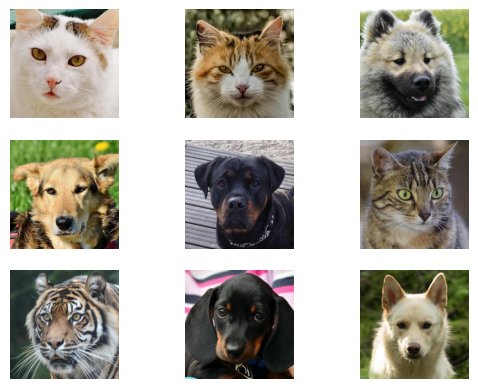

In [10]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
        axarr[row,col].imshow(image)
        axarr[row,col].axis("off")

In [11]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [12]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True )
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE,shuffle= True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE,shuffle= True)


In [13]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(32,64, kernel_size = 3,padding = 1)
        self.conv3 = nn.Conv2d(64,128, kernel_size = 3,padding = 1)

        self.pooling = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear((128*16*16),128)

        self.output = nn.Linear(128, len(df["labels"].unique()))

    def forward(self, x):
        x = self.conv1(x) #(32,128,128)
        x = self.pooling(x) #(32,64,64)
        x = self.relu(x)

        x = self.conv2(x) #(64,64,64)
        x = self.pooling(x) #(64,32,32)
        x = self.relu(x)

        x = self.conv3(x) # (128,32,32)
        x = self.pooling(x) #(128,16,16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)
        return x

In [14]:
model = Net().to(device)

In [16]:
from torchsummary import summary
summary(model, input_size = (3,128,128) )

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)


In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for inputs, labels in train_loader:

        labels = labels.long()
        optimizer.zero_grad()
        outputs = model(inputs)

        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()

        total_acc_train += train_acc
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            labels = labels.long()
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis= 1)== labels).sum().item()
            total_acc_val += val_acc
            
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()* 100, 4))
    total_acc_validation_plot.append(round(total_acc_val/val_dataset.__len__()* 100, 4))

    print(f"""Epoch: {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy: {round((total_acc_train/train_dataset.__len__())* 100, 4)}
    
    Validation Loss {round(total_loss_val/1000,4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}""")
    print("=============================================================================================")

Epoch: 1/10, Train Loss: 0.3332 Train Accuracy: 80.5332
    
    Validation Loss 0.0405 Validation Accuracy 90.4545
Epoch: 2/10, Train Loss: 0.1431 Train Accuracy: 92.7022
    
    Validation Loss 0.0254 Validation Accuracy 94.1322
Epoch: 3/10, Train Loss: 0.0904 Train Accuracy: 95.4388
    
    Validation Loss 0.0189 Validation Accuracy 95.5785
Epoch: 4/10, Train Loss: 0.0625 Train Accuracy: 96.8293
    
    Validation Loss 0.017 Validation Accuracy 95.6198
Epoch: 5/10, Train Loss: 0.0463 Train Accuracy: 97.5999
    
    Validation Loss 0.0147 Validation Accuracy 96.7355
Epoch: 6/10, Train Loss: 0.0336 Train Accuracy: 98.3084
    
    Validation Loss 0.016 Validation Accuracy 96.3223
Epoch: 7/10, Train Loss: 0.0253 Train Accuracy: 98.6272
    
    Validation Loss 0.0184 Validation Accuracy 96.405
Epoch: 8/10, Train Loss: 0.0174 Train Accuracy: 99.1852
    
    Validation Loss 0.0193 Validation Accuracy 96.2397
Epoch: 9/10, Train Loss: 0.0141 Train Accuracy: 99.4155
    
    Validation

In [35]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for inputs, labels in test_loader:
        labels = labels.long()
        predictions = model(inputs)
        

        acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
        total_acc_test += acc
        test_loss = criterion(predictions,labels)
        total_loss_test += test_loss.item()

print(f"Accuracy Score:{round((total_acc_test/test_dataset.__len__())* 100, 4)} and loss is {round(total_loss_test/1000, 4)} ")

Accuracy Score:96.0314 and loss is 0.0196 


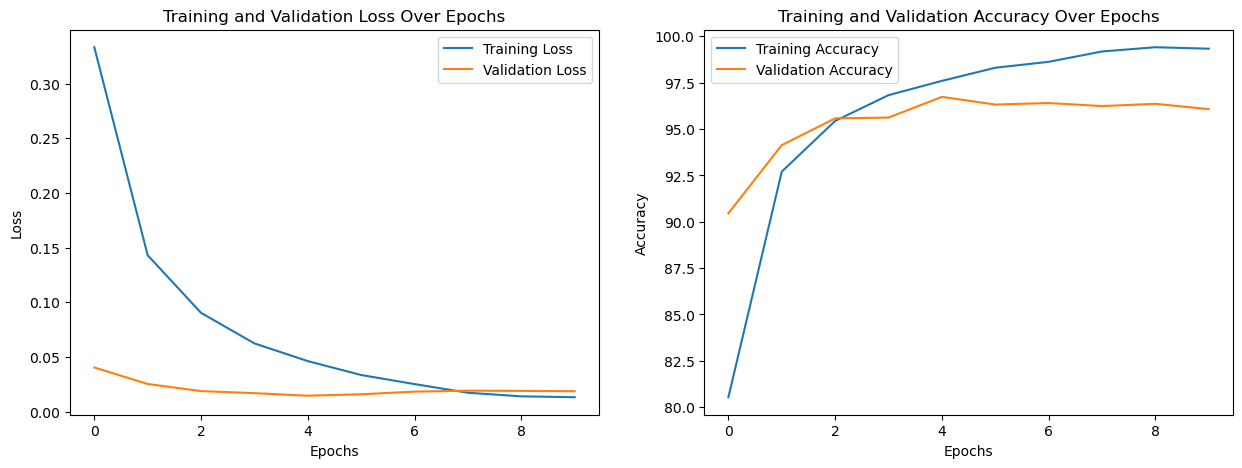

In [37]:
fig , axs = plt.subplots(nrows=1,ncols=2, figsize = (15,5))
axs[0].plot(total_loss_train_plot,label = "Training Loss")
axs[0].plot(total_loss_validation_plot,label = "Validation Loss")
axs[0].set_title("Training and Validation Loss Over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_acc_train_plot,label = "Training Accuracy")
axs[1].plot(total_acc_validation_plot,label = "Validation Accuracy")
axs[1].set_title("Training and Validation Accuracy Over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()

In [39]:
import torch.nn.functional as F

def predict_image(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        probs = F.softmax(output, dim=1)
        confidence, predicted_index = torch.max(probs, dim=1)

    label = label_encoder.inverse_transform([predicted_index.item()])[0]

    return label, confidence.item()

In [92]:
prediction = predict_image("F:/shihtzu (1).webp")
print(prediction)


('dog', 0.9999971389770508)


In [47]:
prediction = predict_image("F:/360_F_174210895_uiy8rcFJqTKP3owkEilpjTNEy9P3zS4j.webp")
print(prediction)

('dog', 0.9999997615814209)


In [49]:
prediction = predict_image("F:/photo-1478098711619-5ab0b478d6e6.webp")
print(prediction)

('dog', 0.9671350121498108)


In [63]:
prediction = predict_image("F:/red-fox-curledup.jpg")
print(prediction)

('dog', 0.9877320528030396)


In [53]:
from collections import Counter
print(Counter(train_dataset.labels))

Counter({tensor(0, device='cuda:0', dtype=torch.int32): 1, tensor(2, device='cuda:0', dtype=torch.int32): 1, tensor(0, device='cuda:0', dtype=torch.int32): 1, tensor(0, device='cuda:0', dtype=torch.int32): 1, tensor(2, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(0, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(0, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(2, device='cuda:0', dtype=torch.int32): 1, tensor(0, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(2, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.int32): 1, tensor(2, device='cuda:0', dtype=torch.int32): 1, tensor(2, device='cuda:0', dtype=torch.int32): 1, tensor(1, device='cuda:0', dtype=torch.in

In [57]:
print(df["labels"].value_counts())

labels
cat     5653
dog     5239
wild    5238
Name: count, dtype: int64


In [59]:
prediction = predict_image("F:/pixabay_cat_002156.jpg")
print(prediction)

('cat', 0.9992601275444031)


In [61]:
prediction = predict_image("F:/Cat+JPG-12.jpg")
print(prediction)

('cat', 0.9999998807907104)


In [75]:
prediction = predict_image("F:/red-fox-vulpes-vulpes-4-years-old-walking.jpg")
print(prediction)

('dog', 1.0)


In [1]:
prediction = predict_image("F:/tired_lion_dad_513989.webp")
print(prediction)

NameError: name 'predict_image' is not defined